In [49]:
import pandas as pd
import os
import re
from pathlib import Path
from collections import defaultdict
import json

class IterativeLotteryAnalyzer:
    def __init__(self, base_path):
        """
        base_path: Path to model/lottery_ticket directory
        """
        self.base_path = Path(base_path)
        self.prune_data = {}
    def get_indiv_concepts(self,formula) -> list:
        concepts = []
        concps = re.findall(r'(?<!\bNOT\s)(?:\b(?:hyp|pre|oth):[^\s)]+)', formula)
        for c in concps:
            try:
                end_idx = c.index(')')
            except:
                end_idx = len(c)
            concepts.append(c[:end_idx])
        return concepts

    def load_all_csvs(self):
        """Load all CSV files from the directory structure"""
        print("Loading CSV files...")
        
        for prune_dir in sorted(self.base_path.iterdir()):
      
            if not prune_dir.is_dir():
                continue
                
            try:
                match = str(prune_dir.name).split("%")
            except:
                continue
                
            prune_level = match[0]
            self.prune_data[prune_level] = {}
            print(prune_level)
            for csv_file in prune_dir.glob('Cluster*'):
                cluster_match = re.search(r'Cluster(\d+)', csv_file.name)
                if not cluster_match:
                    continue
                    
                cluster = cluster_match.group(1)
                
                try:
                    df = pd.read_csv(csv_file)
                    
                    if 'unit' not in df.columns or 'best_name' not in df.columns:
                        print(f"Warning: {csv_file} missing required columns")
                        continue
                    
                    df = df.dropna(subset=['unit', 'best_name'])
                    
                    concepts =[]
                    for row in df['best_name']:
                        concepts.append(set(self.get_indiv_concepts(row)))
                  
                    unit_to_concept = dict(zip(df['unit'], concepts))
                    concept=set()
                    for c in concepts:
                        concept.update(c)
                    self.prune_data[prune_level][cluster] = {
                        'concepts': concept,
                        'unit_to_concept': unit_to_concept,
                        'total_units': len(unit_to_concept),
                        'df': df
                    }
                    
                    
                    print(f"  Loaded: {prune_level}% prune, Cluster {cluster} - {len(concepts)} concepts, {len(unit_to_concept)} units")
                    
                except Exception as e:
                    print(f"Error loading {csv_file}: {e}")
        
        print(f"\nLoaded {len(self.prune_data)} pruning levels\n")
        return self
    def load_csv_data(self,filepath):
        """Load CSV and extract unit-concept mappings. Returns None if file not found."""
        if not Path(filepath).exists():
            return None
        try:
            df = pd.read_csv(filepath)
            unit_concepts = defaultdict(set)
            for _, row in df.iterrows():
                unit = row['unit']
                formula = row['best_name']
                #_, concepts , _= find_abstractions(get_indiv_concepts(formula))
                concepts= self.get_indiv_concepts(formula)
                unit_concepts[unit].update(concepts)
            return unit_concepts
        except Exception as e:
            print(f"  Warning: Could not load {filepath}: {e}")
            return None

    def analyze_iterative_changes(self):
        """Compare each pruning level to the previous one (iteration-to-iteration)"""
        prune_levels = sorted(self.prune_data.keys(), key=float)
        
        if len(prune_levels) < 2:
            print("Need at least 2 pruning levels for iterative analysis")
            return
        
        print(f"\n{'='*80}")
        print(f"ITERATIVE ANALYSIS: Changes Between Consecutive Pruning Levels")
        print(f"{'='*80}\n")
        csv_data_c1 = self.load_csv_data("/workspace/CCE_NLI/BERT/exp/pretrained/Expls/Cluster1IOUS1024N.csv")
        csv_data_c1 = set().union(*csv_data_c1.values())
        
        csv_data_c2 = self.load_csv_data("/workspace/CCE_NLI/BERT/exp/pretrained/Expls/Cluster2IOUS1024N.csv")
        csv_data_c2 = set().union(*csv_data_c2.values())
        
        csv_data_c3 = self.load_csv_data("/workspace/CCE_NLI/BERT/exp/pretrained/Expls/Cluster3IOUS1024N.csv")
        csv_data_c3 = set().union(*csv_data_c3.values())
        datas={'1':csv_data_c1, '2':csv_data_c2, '3':csv_data_c3}
        results = []
        baselines={}
        unique_to_iter={'1':set(), '2':set(), '3':set()}
        for i in range(len(prune_levels) - 1):
            prev_level = prune_levels[i]
            curr_level = prune_levels[i + 1]
            
            prev_data = self.prune_data[prev_level]
            curr_data = self.prune_data[curr_level]
            
            print(f"\n{'='*80}")
            print(f"FROM {prev_level}% → TO {curr_level}% PRUNING")
            print(f"{'='*80}")
            
            # Per-cluster analysis
            cluster_analysis = {}
            
            for cluster in sorted(curr_data.keys(), key=int):
                if cluster not in prev_data:
                    continue
                prev_cluster = prev_data[cluster]
                curr_cluster = curr_data[cluster]
                
                prev_concepts = prev_cluster['concepts']
                curr_concepts = curr_cluster['concepts']
                
                preserved = curr_concepts & prev_concepts
                lost = prev_concepts - curr_concepts
                new_concepts = curr_concepts - prev_concepts
                
                if prev_level=='0.0':
                    #unique_to_iter[cluster]=unique_to_iter[cluster].union(prev_concepts)
                    num_relearned=0
                    percent_relearned=0
                    numprevlost=0
                    baselines[cluster]=prev_concepts
        
                else:
                    num_relearned=len(new_concepts & prev_lost)
                    percent_relearned=num_relearned/len(prev_lost)
                    numprevlost=len(prev_lost)
                    unique_to_iter[cluster]=unique_to_iter[cluster].union(curr_concepts-baselines[cluster]-datas[cluster])
                    
                prev_lost=lost
                
                preservation_rate = (len(preserved) / len(prev_concepts) * 100) if prev_concepts else 0
                
                # Unit changes
                units_removed = prev_cluster['total_units'] - curr_cluster['total_units']
                units_removal_pct = (units_removed / prev_cluster['total_units'] * 100) if prev_cluster['total_units'] else 0
                
                cluster_analysis[cluster] = {
                    'preserved': len(preserved),
                    'lost': len(lost),
                    'new': len(new_concepts),
                    'preserved_list': sorted(preserved),
                    'lost_list': sorted(lost),
                    'new_list': sorted(new_concepts),
                    'prev_units': prev_cluster['total_units'],
                    'curr_units': curr_cluster['total_units'],
                    'units_removed': units_removed,
                    'units_removal_pct': units_removal_pct,
                    'preservation_rate': preservation_rate,
                    'num_relearned':num_relearned,
                    'percent_relearned':percent_relearned,
                    'prev_lost':numprevlost
                }
                
                '''print(f"\n  percent of lost that are in pretrained  {len(lost &datas[cluster])/len(lost)}:")
                print(f"\n  percent of lost that are in baselines  {len(lost &baselines[cluster])/len(lost)}:")
                print(f"\n  percent of lost that are in baseline&pretrained {len(lost &baselines[cluster]&datas[cluster])/len(lost)}:")
                print(f"\n  percent of lost that are in baseline&!pretrained {len(lost &baselines[cluster]-datas[cluster])/len(lost)}:")
                print(f"\n  percent of lost that are in !baseline&pretrained {len(lost &datas[cluster]-baselines[cluster])/len(lost)}:")
                print(f"\n  percent of lost that are not in baseline nor pretrained, they are in the {prev_level} at cluster {cluster} , {len(lost - datas[cluster]-baselines[cluster])/len(lost)}:")
                
                print(f"\n  percent of new concepts that are in baseline&pretrained {len(new_concepts &baselines[cluster]&datas[cluster])/len(new_concepts)}:")
                print(f"\n  percent of new concepts that are in baseline&!pretrained {len(new_concepts &baselines[cluster]-datas[cluster])/len(new_concepts)}:")
                print(f"\n  percent of new concepts that are in !baseline&pretrained {len(new_concepts &datas[cluster]-baselines[cluster])/len(new_concepts)}:")'''
                
                print(f"\n  Cluster {cluster}:")
                #lost concpets
                print("% of lost concepts that are lost from")
                print("\t\t dense&pretrained&previous_iter:", len(baselines[cluster]&datas[cluster]&prev_concepts&lost)/len(lost))
                print("\t\t dense&pretrained&notprevious_iter:", len(baselines[cluster]&datas[cluster]&lost-prev_concepts)/len(lost))
                
                print("\t\t pretrained but NOT dense&previous_iter:", len(datas[cluster]-baselines[cluster]&prev_concepts&lost)/len(lost))
                print("\t\t pretrained but NOT dense&!previous_iter:", len(datas[cluster]-baselines[cluster]&lost-prev_concepts)/len(lost))
                
                print("\t\t dense but NOT pretrained&previous_iter:", len(baselines[cluster]-datas[cluster]&prev_concepts&lost)/len(lost))
                print("\t\t previous_iter but not from dense nor pretrained:", len(prev_concepts-baselines[cluster]-datas[cluster]&lost)/len(lost))
                
                
                #new concepts
                
                print("% of new concepts that come from")
                truly_new = new_concepts - baselines[cluster] - datas[cluster] - unique_to_iter[cluster]
                print("\t\t truly brand new (never seen, not dense, not pt):", len(truly_new)/len(new_concepts))
                print("\t\t dense&pretrained:", len(baselines[cluster]&datas[cluster]&new_concepts)/len(new_concepts))
                print("\t\t pretrained but NOT dense:", len(datas[cluster]-baselines[cluster]&new_concepts)/len(new_concepts))
                print("\t\t dense but NOT pretrained:", len(baselines[cluster]-datas[cluster]&new_concepts)/len(new_concepts))
                print("\t\t not from dense nor pretrained:", len(new_concepts-baselines[cluster]-datas[cluster])/len(new_concepts))
                
               
                #existing concepts
                print("% of existing concepts that come from")
                print("\t\t dense&pretrained&previous_iter:", len(baselines[cluster]&datas[cluster]&prev_concepts&curr_concepts)/len(curr_concepts))
                print("\t\t dense&pretrained& not previous_iter:", len(baselines[cluster]&datas[cluster]-prev_concepts&curr_concepts)/len(curr_concepts))
                print("\t\t pretrained but NOT dense&previous_iter:", len(datas[cluster]-baselines[cluster]&prev_concepts&curr_concepts)/len(curr_concepts))
                print("\t\t pretrained but NOT dense& not previous_iter:", len(datas[cluster]-baselines[cluster]-prev_concepts&curr_concepts)/len(curr_concepts))
                print("\t\t dense but NOT pretrained&previous_iter:", len(baselines[cluster]-datas[cluster]&prev_concepts&curr_concepts)/len(curr_concepts))
                print("\t\t dense but NOT pretrained and not previous_iter:", len(baselines[cluster]-datas[cluster]-prev_concepts&curr_concepts)/len(curr_concepts))
                print("\t\t previous_iter but not from dense nor pretrained:", len(prev_concepts-baselines[cluster]-datas[cluster]&curr_concepts)/len(curr_concepts))
                print("\t\t not previous_iter , not from dense nor pretrained:", len(curr_concepts-prev_concepts-baselines[cluster]-datas[cluster])/len(curr_concepts))
                
                
                '''print(f"    Units: {prev_cluster['total_units']} → {curr_cluster['total_units']} (removed {units_removed}, {units_removal_pct:.1f}%)")
                print(f"    Concepts: {len(prev_concepts)} → {len(curr_concepts)}")
                print(f"    Preserved: {len(preserved)} ({preservation_rate:.1f}%)")
                print(f"    Lost: {len(lost)}")
                print(f"    New: {len(new_concepts)}")
                print(f"    num_relearned: {num_relearned}")
                print(f"    percent_relearned: {percent_relearned}")
                print(f"    prev_lost: {numprevlost}")
          
                if lost and len(lost) <= 10:
                    print(f"    Lost concepts: {', '.join(sorted(lost))}")
                elif lost:
                    print(f"    Lost concepts (sample): {', '.join(list(sorted(lost)))}")
                
                if new_concepts and len(new_concepts) <= 10:
                    print(f"    New concepts: {', '.join(sorted(new_concepts))}")
                elif new_concepts:
                    print(f"    New concepts (sample): {', '.join(list(sorted(new_concepts)))}...")'''
            
            # Global analysis
            all_prev_concepts = set()
            all_curr_concepts = set()
            for cluster_data in prev_data.values():
                all_prev_concepts.update(cluster_data['concepts'])
            for cluster_data in curr_data.values():
                all_curr_concepts.update(cluster_data['concepts'])
            
            global_preserved = all_curr_concepts & all_prev_concepts
            global_lost = all_prev_concepts - all_curr_concepts
            global_new = all_curr_concepts - all_prev_concepts
            
            global_preservation_rate = (len(global_preserved) / len(all_curr_concepts) * 100) if all_prev_concepts else 0
            
            if prev_level=='0.0':
                percent_relearned = 0
                num_relearned = 0
                num_lost = 0
                baseline=all_prev_concepts
            else:
                percent_relearned = len(global_new & prev_global_lost)/len(prev_global_lost)
                num_relearned = len(global_new & prev_global_lost)
                num_lost = len(prev_global_lost)
            print(f"\n  GLOBAL CHANGES:")
            '''print(f"    Total Concepts: {len(all_prev_concepts)} → {len(all_curr_concepts)}")
            print(f"    Preservation Rate from prev oter: {global_preservation_rate:.1f}%")
            print(f"    Lost in this step: {len(global_lost)}")
            print(f"    New in this step: {len(global_new)}")
            print(f"    percent_relearned in this step: {percent_relearned}")
            print(f"    num_relearned in this step: {num_relearned}")
            print(f"    num_lost in prev step: {num_lost}")'''
            print(f"    globally preservred from og: {len(baseline & all_curr_concepts)}/{len(all_curr_concepts)}= {len(baseline & all_curr_concepts) / len(all_curr_concepts)}")
            print(f"    globally preservred from og: {len(baseline & all_curr_concepts & csv_data_c1|csv_data_c2|csv_data_c3)}/{len(all_curr_concepts)}= {len(baseline & all_curr_concepts & csv_data_c1|csv_data_c2|csv_data_c3) / len(all_curr_concepts)}")
            
            ''''if global_lost:
                print(f"\n    Globally Lost Concepts in this step:")
                print(sorted(global_lost))
                print(f"total {len(global_lost)}")
            
            if global_new:
                print(f"\n    Globally New Concepts in this step:")
                print(sorted(global_new))
                print(f"total {len(global_new)}")
            
            results.append({
                'from_level': prev_level,
                'to_level': curr_level,
                'clusters': cluster_analysis,
                'global': {
                    'prev_total': len(all_prev_concepts),
                    'curr_total': len(all_curr_concepts),
                    'preserved': len(global_preserved),
                    'lost': len(global_lost),
                    'new': len(global_new),
                    'preservation_rate': global_preservation_rate,
                    'lost_concepts': sorted(global_lost),
                    'new_concepts': sorted(global_new),
                    'num_relearned': num_relearned,
                }
            })'''
            prev_global_lost=global_lost
        
        return results
    
    def concept_survival_rate(self):
        """Track which concepts survive the longest and which die first"""
        prune_levels = sorted(self.prune_data.keys(), key=int)
        
        print(f"\n{'='*80}")
        print(f"CONCEPT SURVIVAL ANALYSIS")
        print(f"{'='*80}\n")
        
        # Get all concepts from baseline
        baseline = self.prune_data[prune_levels[0]]
        all_concepts = set()
        for cluster_data in baseline.values():
            all_concepts.update(cluster_data['concepts'])
        
        # Track when each concept is lost
        concept_survival = {}
        for concept in all_concepts:
            last_seen = None
            for level in prune_levels:
                # Check if concept exists in this level
                exists = False
                for cluster_data in self.prune_data[level].values():
                    if concept in cluster_data['concepts']:
                        exists = True
                        last_seen = level
                        break
                if not exists and last_seen is not None:
                    break
            concept_survival[concept] = last_seen if last_seen else prune_levels[0]
        
        # Group by survival level
        survival_groups = defaultdict(list)
        for concept, last_level in concept_survival.items():
            survival_groups[last_level].append(concept)
        
        print("Concepts lost at each pruning step:\n")
        for level in prune_levels[1:]:  # Skip baseline
            prev_level = str(int(level) - (int(prune_levels[1]) - int(prune_levels[0])))
            if prev_level in survival_groups:
                concepts_lost = [c for c in survival_groups[prev_level]]
                if concepts_lost:
                    print(f"  Lost between {prev_level}% → {level}%: {len(concepts_lost)} concepts")
                    if len(concepts_lost) <= 15:
                        for c in sorted(concepts_lost):
                            print(f"    - {c}")
                    else:
                        for c in sorted(concepts_lost)[:10]:
                            print(f"    - {c}")
                        print(f"    ... and {len(concepts_lost) - 10} more")
                    print()
        
        # Survivors
        final_level = prune_levels[-1]
        survivors = survival_groups[final_level]
        print(f"\n  Concepts surviving to {final_level}% pruning: {len(survivors)}")
        if len(survivors) <= 30:
            print(f"  Survivors:")
            for c in sorted(survivors):
                print(f"    ✓ {c}")
        else:
            print(f"  Top survivors (sample):")
            for c in sorted(survivors)[:20]:
                print(f"    ✓ {c}")
            print(f"    ... and {len(survivors) - 20} more")
        
        return survival_groups
    
    def cluster_transfer_analysis(self):
        """Analyze if concepts move between clusters during pruning"""
        prune_levels = sorted(self.prune_data.keys(), key=int)
        
        print(f"\n{'='*80}")
        print(f"CLUSTER TRANSFER ANALYSIS")
        print(f"{'='*80}\n")
        
        for i in range(len(prune_levels) - 1):
            prev_level = prune_levels[i]
            curr_level = prune_levels[i + 1]
            
            print(f"\nFrom {prev_level}% → {curr_level}%:")
            
            # Track where each concept was and where it is now
            prev_concept_clusters = defaultdict(set)
            curr_concept_clusters = defaultdict(set)
            
            for cluster, cluster_data in self.prune_data[prev_level].items():
                for concept in cluster_data['concepts']:
                    prev_concept_clusters[concept].add(cluster)
            
            for cluster, cluster_data in self.prune_data[curr_level].items():
                for concept in cluster_data['concepts']:
                    curr_concept_clusters[concept].add(cluster)
            
            # Find concepts that changed clusters
            transferred = []
            for concept in curr_concept_clusters:
                if concept in prev_concept_clusters:
                    if prev_concept_clusters[concept] != curr_concept_clusters[concept]:
                        transferred.append({
                            'concept': concept,
                            'from': sorted(prev_concept_clusters[concept]),
                            'to': sorted(curr_concept_clusters[concept])
                        })
            
            if transferred:
                print(f"  Concepts that moved clusters: {len(transferred)}")
                for item in transferred[:15]:  # Show first 15
                    print(f"    '{item['concept']}': clusters {item['from']} → {item['to']}")
                if len(transferred) > 15:
                    print(f"    ... and {len(transferred) - 15} more")
            else:
                print(f"  No concepts transferred between clusters")
    
    def save_results(self, results, output_file='iterative_analysis_resultsBowman.json'):
        """Save analysis results to JSON"""
        def convert_sets(obj):
            if isinstance(obj, set):
                return sorted(list(obj))
            elif isinstance(obj, dict):
                return {k: convert_sets(v) for k, v in obj.items()}
            elif isinstance(obj, list):
                return [convert_sets(item) for item in obj]
            return obj
        
        results_serializable = convert_sets(results)
        
        with open(output_file, 'w') as f:
            json.dump(results_serializable, f, indent=2)
        print(f"\n\nResults saved to {output_file}")


# Example usage
if __name__ == "__main__":
    base_path = "/workspace/CCE_NLI/BERT/exp/lottery_ticket/Run0.25_5/Expls"  # Adjust this path
    
    analyzer = IterativeLotteryAnalyzer(base_path)
    analyzer.load_all_csvs()
    
    # Main iterative analysis (step-by-step changes)
    print("\n" + "="*80)
    print("RUNNING ITERATIVE ANALYSIS")
    print("="*80)
    results = analyzer.analyze_iterative_changes()
    analyzer.save_results(results)
    
    # Survival analysis (which concepts die first/last)
    analyzer.concept_survival_rate()
    
    # Transfer analysis (concepts moving between clusters)
    analyzer.cluster_transfer_analysis()
    
    print("\n\nAnalysis complete!")



Loading CSV files...
0.0
  Loaded: 0.0% prune, Cluster 2 - 1024 concepts, 1024 units
  Loaded: 0.0% prune, Cluster 3 - 934 concepts, 934 units
  Loaded: 0.0% prune, Cluster 1 - 1024 concepts, 1024 units
25.0
  Loaded: 25.0% prune, Cluster 1 - 1024 concepts, 1024 units
  Loaded: 25.0% prune, Cluster 2 - 1024 concepts, 1024 units
  Loaded: 25.0% prune, Cluster 3 - 942 concepts, 942 units
43.75
  Loaded: 43.75% prune, Cluster 1 - 1024 concepts, 1024 units
  Loaded: 43.75% prune, Cluster 2 - 1024 concepts, 1024 units
  Loaded: 43.75% prune, Cluster 3 - 954 concepts, 954 units
57.812
  Loaded: 57.812% prune, Cluster 1 - 1024 concepts, 1024 units
  Loaded: 57.812% prune, Cluster 2 - 1024 concepts, 1024 units
  Loaded: 57.812% prune, Cluster 3 - 977 concepts, 977 units
68.359
  Loaded: 68.359% prune, Cluster 1 - 1024 concepts, 1024 units
  Loaded: 68.359% prune, Cluster 2 - 1024 concepts, 1024 units
  Loaded: 68.359% prune, Cluster 3 - 982 concepts, 982 units
76.27
  Loaded: 76.27% prune, Clu

ValueError: invalid literal for int() with base 10: '0.0'

Found 1 run(s):
  /workspace/CCE_NLI/BERT/exp/wanda/Run0.25_5/Expls

Loading pretrained concepts...
  Pretrained cluster 1: 226 concepts
  Pretrained cluster 2: 217 concepts
  Pretrained cluster 3: 203 concepts

--- Processing run: /workspace/CCE_NLI/BERT/exp/wanda/Run0.25_5/Expls ---

Averaging across 1 run(s)...

Figure saved to concept_origins_averaged.png


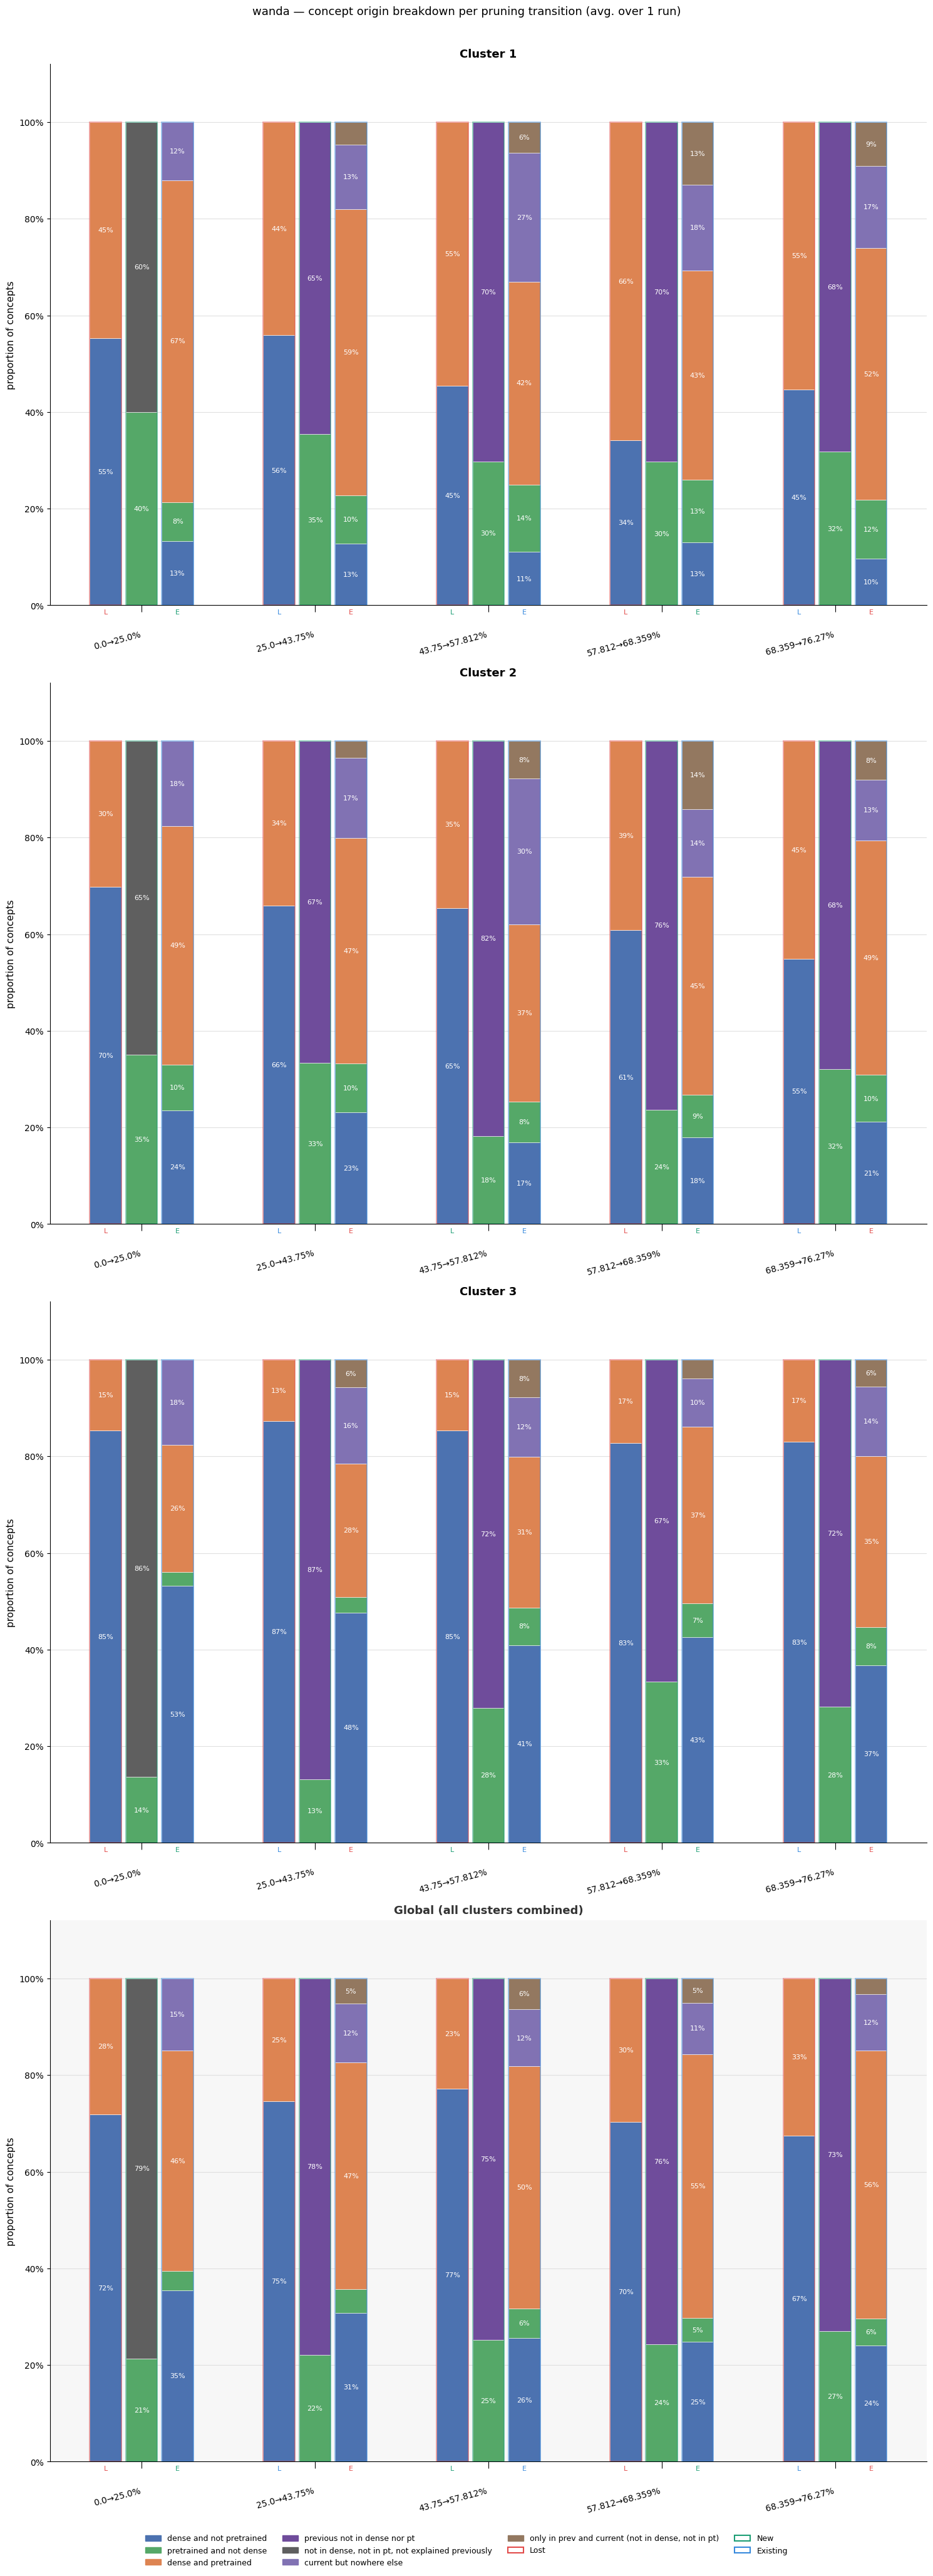

In [8]:
import pandas as pd
import re
from pathlib import Path
from collections import defaultdict
import json
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

COLORS = {
    "dense_only":      "#4C72B0",
    "pt_only":         "#55A868",
    "dense&pt":        "#DD8452",
    "explained_previously_but_not_in_dense_nor_pt": "#6F4C9B",
    "truly_novel":     "#5F5F5F",
    "new":             "#8172B3",
    "unique to prev":  "#937860",
}

LEGEND_LABELS = {
    "dense_only":   "dense and not pretrained",
    "pt_only":      "pretrained and not dense",
    "dense&pt":     "dense and pretrained",
    "explained_previously_but_not_in_dense_nor_pt": "previous not in dense nor pt",
    "truly_novel":  "not in dense, not in pt, not explained previously",
    "new":          "current but nowhere else",
    "unique to prev": "only in prev and current (not in dense, not in pt)",
}
CAT_KEYS = list(COLORS.keys())
ZERO_FRACS = {k: 0.0 for k in CAT_KEYS}

GLOBAL_CLUSTER_KEY = "GLOBAL"   # sentinel key for the all-cluster panel


def _safe(num, denom):
    return num / denom if denom else 0.0


def _origin_fracs(concept_set, baseline, pretrained, unique_iter,
                  concept_type, prev_concepts=None, method=None):
    n = len(concept_set)
    if n == 0:
        return dict(ZERO_FRACS)

    truly_new = concept_set - baseline - pretrained - unique_iter

    if concept_type == "new":
        return {
            "dense&pt":   _safe(len(baseline & pretrained & concept_set), n),
            "dense_only": _safe(len((baseline - pretrained) & concept_set), n),
            "pt_only":    _safe(len((concept_set & pretrained) - baseline), n),
            "explained_previously_but_not_in_dense_nor_pt":
                          _safe(len(unique_iter & concept_set), n),
            "truly_novel": _safe(len(truly_new), n),
            "unique to prev": 0.0,
            "new": 0.0,
        }
    else:
        # lost / existing — partition into 5 mutually exclusive buckets
        return {
            "dense&pt":    _safe(len(concept_set & baseline & pretrained), n),
            "dense_only":  _safe(len((concept_set & baseline) - pretrained), n),
            "pt_only":     _safe(len((concept_set & pretrained) - baseline), n),
            "unique to prev":
                           _safe(len((concept_set & prev_concepts) - pretrained - baseline), n),
            "new":         _safe(len(concept_set - prev_concepts - pretrained - baseline), n),
            "explained_previously_but_not_in_dense_nor_pt": 0.0,
            "truly_novel": 0.0,
        }


def _average_frac_lists(all_run_fracs):
    """
    all_run_fracs : list[run] of list[transition] of frac-dicts
    Returns       : (avg_list, std_list) each list[transition] of dicts
    """
    if not all_run_fracs:
        return [], []
    n_transitions = max(len(r) for r in all_run_fracs)
    avg_list, std_list = [], []
    for ti in range(n_transitions):
        dicts_at_ti = [r[ti] for r in all_run_fracs if ti < len(r)]
        avg, std = {}, {}
        for key in CAT_KEYS:
            vals = [d[key] for d in dicts_at_ti]
            avg[key] = float(np.mean(vals))
            std[key] = float(np.std(vals))
        avg_list.append(avg)
        std_list.append(std)
    return avg_list, std_list


class MultiRunLotteryAnalyzer:
    """
    Discovers all Run* subdirectories, runs the iterative analysis on each,
    averages across runs, and plots one subplot per cluster PLUS one extra
    subplot for global concepts (union of all clusters at each transition).
    """

    def __init__(self, experiment_dir, pretrained_base_dir,
                 cluster_csv_pattern="Cluster{n}IOUS1024N.csv",
                 n_clusters=3):
        self.experiment_dir      = Path(experiment_dir)
        self.pretrained_base_dir = Path(pretrained_base_dir)
        self.cluster_csv_pattern = cluster_csv_pattern
        self.n_clusters          = n_clusters

        p = str(experiment_dir).lower()
        if 'lottery_ticket' in p:
            self.method = 'LTH'
        elif 'wanda' in p:
            self.method = 'wanda'
        elif 'cofi' in p:
            self.method = 'CoFi'
        else:
            self.method = 'unknown'

    # ------------------------------------------------------------------ #
    # Run discovery                                                        #
    # ------------------------------------------------------------------ #

    def _find_run_dirs(self):
        run_dirs = []
        for d in sorted(self.experiment_dir.iterdir()):
            if not d.is_dir():
                continue
            if any(x in str(d) for x in ('4cl', '8', '6', '7')):
                continue
            expls = d / "Expls"
            if expls.is_dir():
                run_dirs.append(expls)
            elif d.name.lower().startswith("run"):
                run_dirs.append(d)
        if not run_dirs:
            raise FileNotFoundError(
                f"No Run*/Expls directories found under {self.experiment_dir}"
            )
        print(f"Found {len(run_dirs)} run(s):")
        for r in run_dirs:
            print(f"  {r}")
        return run_dirs

    # ------------------------------------------------------------------ #
    # Pretrained concept loading                                          #
    # ------------------------------------------------------------------ #

    def _load_pretrained_concepts(self):
        datas = {}
        for n in range(1, self.n_clusters + 1):
            fname = self.cluster_csv_pattern.format(n=n)
            fpath = self.pretrained_base_dir / fname
            if not fpath.exists():
                print(f"  Warning: pretrained file not found: {fpath}")
                datas[str(n)] = set()
                continue
            df = pd.read_csv(fpath)
            unit_concepts = defaultdict(set)
            for _, row in df.iterrows():
                for c in self._get_indiv_concepts(str(row.get('best_name', ''))):
                    unit_concepts[row['unit']].add(c)
            datas[str(n)] = set().union(*unit_concepts.values())
            print(f"  Pretrained cluster {n}: {len(datas[str(n)])} concepts")

        # global pretrained = union across all cluster pretrained sets
        datas[GLOBAL_CLUSTER_KEY] = set().union(*datas.values())
        return datas

    # ------------------------------------------------------------------ #
    # Helpers                                                              #
    # ------------------------------------------------------------------ #

    @staticmethod
    def _get_indiv_concepts(formula):
        concepts = []
        concps = re.findall(r'(?<!\bNOT\s)(?:\b(?:hyp|pre|oth):[^\s)]+)', formula)
        for c in concps:
            try:
                end_idx = c.index(')')
            except Exception:
                end_idx = len(c)
            concepts.append(c[:end_idx])
        return concepts

    def _load_run(self, expls_path):
        prune_data = {}
        for prune_dir in sorted(expls_path.iterdir()):
            if not prune_dir.is_dir():
                continue
            prune_level = prune_dir.name.split("%")[0]
            prune_data[prune_level] = {}
            for csv_file in prune_dir.glob('Cluster*'):
                m = re.search(r'Cluster(\d+)', csv_file.name)
                if not m:
                    continue
                cluster = m.group(1)
                try:
                    df = pd.read_csv(csv_file).dropna(subset=['unit', 'best_name'])
                    concepts_per_unit = [
                        set(self._get_indiv_concepts(r)) for r in df['best_name']
                    ]
                    all_concepts = set().union(*concepts_per_unit) if concepts_per_unit else set()
                    prune_data[prune_level][cluster] = {
                        'concepts': all_concepts,
                        'unit_to_concept': dict(zip(df['unit'], concepts_per_unit)),
                        'total_units': len(df),
                    }
                except Exception as e:
                    print(f"    Error loading {csv_file}: {e}")

            # add a synthetic GLOBAL entry = union of all clusters at this level
            if prune_data[prune_level]:
                global_concepts = set().union(
                    *(v['concepts'] for v in prune_data[prune_level].values())
                )
                prune_data[prune_level][GLOBAL_CLUSTER_KEY] = {
                    'concepts': global_concepts,
                    'unit_to_concept': {},
                    'total_units': 0,
                }
        return prune_data

    # ------------------------------------------------------------------ #
    # Single-run analysis                                                  #
    # ------------------------------------------------------------------ #

    def _analyze_single_run(self, prune_data, datas):
        prune_levels   = sorted(prune_data.keys(), key=float)
        # include GLOBAL_CLUSTER_KEY in the cluster list
        per_cluster_keys = sorted(
            [k for k in next(iter(prune_data.values())).keys()
             if k != GLOBAL_CLUSTER_KEY],
            key=int
        )
        all_keys = per_cluster_keys + [GLOBAL_CLUSTER_KEY]

        plot_data = {c: {"lost": [], "new": [], "existing": []} for c in all_keys}
        transition_labels = []

        baselines      = {}
        unique_to_iter = {c: set() for c in all_keys}
        prev_lost      = {}

        for i in range(len(prune_levels) - 1):
            prev_level = prune_levels[i]
            curr_level = prune_levels[i + 1]
            prev_data  = prune_data[prev_level]
            curr_data  = prune_data[curr_level]

            transition_labels.append(f"{prev_level}→{curr_level}%")

            for cluster in all_keys:
                if cluster not in prev_data or cluster not in curr_data:
                    for ctype in ("lost", "new", "existing"):
                        plot_data[cluster][ctype].append(dict(ZERO_FRACS))
                    continue

                prev_concepts = prev_data[cluster]['concepts']
                curr_concepts = curr_data[cluster]['concepts']
                

                # use the right pretrained set (global or per-cluster)
                pt = datas.get(cluster, datas.get(GLOBAL_CLUSTER_KEY, set()))

                if prev_level == '0.0':
                    baselines[cluster] = prev_concepts
                else:
                    unique_to_iter[cluster] = unique_to_iter[cluster].union(
                        curr_concepts - baselines.get(cluster, set()) - pt
                    )

                
                lost          = baselines[cluster]  - curr_concepts
                new_concepts  = curr_concepts - baselines[cluster] 

                prev_lost[cluster] = lost
                
                b  = baselines.get(cluster, set())
                ui = unique_to_iter[cluster]

                plot_data[cluster]["lost"].append(
                    _origin_fracs(lost, b, pt, ui, "lost", prev_concepts, method=self.method)
                )
                plot_data[cluster]["new"].append(
                    _origin_fracs(new_concepts, b, pt, ui, "new", method=self.method)
                )
                plot_data[cluster]["existing"].append(
                    _origin_fracs(curr_concepts, b, pt, ui, "existing", prev_concepts, method=self.method)
                )

        return plot_data, transition_labels

    # ------------------------------------------------------------------ #
    # Main entry point                                                     #
    # ------------------------------------------------------------------ #

    def run(self, save_path="concept_origins_averaged.png"):
        run_dirs = self._find_run_dirs()
        print("\nLoading pretrained concepts...")
        datas = self._load_pretrained_concepts()

        all_plot_data  = defaultdict(lambda: {"lost": [], "new": [], "existing": []})
        transition_labels = None
        all_keys          = None

        for run_path in run_dirs:
            print(f"\n--- Processing run: {run_path} ---")
            prune_data = self._load_run(run_path)
            if not prune_data:
                print("  No data found, skipping.")
                continue

            run_plot_data, run_labels = self._analyze_single_run(prune_data, datas)

            if transition_labels is None:
                transition_labels = run_labels
            if all_keys is None:
                # per-cluster keys sorted numerically, then GLOBAL last
                per_cluster = sorted(
                    [k for k in run_plot_data if k != GLOBAL_CLUSTER_KEY], key=int
                )
                all_keys = per_cluster + [GLOBAL_CLUSTER_KEY]

            for cluster in run_plot_data:
                for ctype in ("lost", "new", "existing"):
                    all_plot_data[cluster][ctype].append(run_plot_data[cluster][ctype])

        if not transition_labels:
            print("No transitions found across any run.")
            return

        print(f"\nAveraging across {len(run_dirs)} run(s)...")
        avg_plot_data = {}
        std_plot_data = {}
        for cluster in all_keys:
            avg_plot_data[cluster] = {}
            std_plot_data[cluster] = {}
            for ctype in ("lost", "new", "existing"):
                avg, std = _average_frac_lists(all_plot_data[cluster][ctype])
                avg_plot_data[cluster][ctype] = avg
                std_plot_data[cluster][ctype] = std

        self._plot_stacked_bars(
            avg_plot_data, std_plot_data,
            transition_labels, all_keys,
            n_runs=len(run_dirs), save_path=save_path,
        )

    # ------------------------------------------------------------------ #
    # Plotting                                                             #
    # ------------------------------------------------------------------ #

    def _plot_stacked_bars(self, avg_data, std_data,
                           transition_labels, clusters,
                           n_runs=1, save_path="concept_origins_averaged.png"):

        n_transitions = len(transition_labels)
        concept_types = ["lost", "new", "existing"]
        type_border   = {"lost": "#E24B4A", "new": "#1D9E75", "existing": "#378ADD"}

        bar_w     = 0.22
        group_gap = 0.18
        offsets   = {ct: (j - 1) * bar_w for j, ct in enumerate(concept_types)}
        x_centers = np.arange(n_transitions) * (len(concept_types) * bar_w + group_gap + bar_w)

        n_panels = len(clusters)   # per-cluster subplots + 1 global subplot

        fig, axes = plt.subplots(
            n_panels, 1,
            figsize=(max(12, n_transitions * 3), 10 * n_panels),
            sharey=True,
        )
        if n_panels == 1:
            axes = [axes]

        for ci, cluster in enumerate(clusters):
            ax = axes[ci]
            is_global = (cluster == GLOBAL_CLUSTER_KEY)

            for ctype in concept_types:
                avg_list = avg_data[cluster][ctype]
                std_list = std_data[cluster][ctype]
                x_pos    = x_centers + offsets[ctype]
                bottoms  = np.zeros(n_transitions)

                for key in CAT_KEYS:
                    vals = np.array([f[key] for f in avg_list])
                    stds = np.array([f[key] for f in std_list])

                    bars = ax.bar(
                        x_pos, vals,
                        width=bar_w * 0.88,
                        bottom=bottoms,
                        color=COLORS[key],
                        edgecolor="white",
                        linewidth=0.4,
                        zorder=3,
                    )

                    if n_runs > 1:
                        ax.errorbar(
                            x_pos, bottoms + vals, yerr=stds,
                            fmt="none", ecolor="black",
                            elinewidth=0.8, capsize=2,
                            zorder=5, alpha=0.5,
                        )

                    for rect, v, b in zip(bars, vals, bottoms):
                        if v > 0.05:
                            ax.text(
                                rect.get_x() + rect.get_width() / 2,
                                b + v / 2,
                                f"{v:.0%}",
                                ha="center", va="center",
                                fontsize=8, color="white", zorder=6,
                            )
                    bottoms += vals

                for xp in x_pos:
                    ax.bar(xp, 1.0, width=bar_w * 0.88, bottom=0,
                           fill=False, edgecolor=type_border[ctype],
                           linewidth=1.2, zorder=4, alpha=0.55)

            ax.set_xticks(x_centers)
            ax.set_xticklabels(transition_labels, fontsize=10, rotation=15, ha="right")

            minor_pos, minor_lab = [], []
            abbrev = {"lost": "L", "new": "N", "existing": "E"}
            for xc in x_centers:
                for ctype in concept_types:
                    minor_pos.append(xc + offsets[ctype])
                    minor_lab.append(abbrev[ctype])
            ax.set_xticks(minor_pos, minor=True)
            ax.set_xticklabels(minor_lab, minor=True, fontsize=8)
            ax.tick_params(axis="x", which="major", length=8, pad=20)
            ax.tick_params(axis="x", which="minor", length=0, pad=4)

            for tick, ctype in zip(ax.xaxis.get_minor_ticks(), concept_types * n_transitions):
                tick.label1.set_color(type_border[ctype])

            ax.set_ylim(0, 1.12)
            ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
            ax.tick_params(axis="y", labelsize=10)
            ax.set_ylabel("proportion of concepts", fontsize=11)

            # visually distinguish the global panel
            if is_global:
                ax.set_title("Global (all clusters combined)",
                             fontsize=13, fontweight="bold", pad=8,
                             color="#333333")
                ax.set_facecolor("#f7f7f7")
            else:
                ax.set_title(f"Cluster {cluster}",
                             fontsize=13, fontweight="bold", pad=8)

            ax.spines[["top", "right"]].set_visible(False)
            ax.grid(axis="y", color="#e0e0e0", linewidth=0.8, zorder=0)
            ax.set_axisbelow(True)

        origin_patches = [
            mpatches.Patch(color=COLORS[k], label=LEGEND_LABELS[k]) for k in CAT_KEYS
        ]
        type_patches = [
            mpatches.Patch(facecolor="white", edgecolor=type_border[ct],
                           linewidth=1.5, label=ct.capitalize())
            for ct in concept_types
        ]
        fig.legend(
            handles=origin_patches + type_patches,
            loc="lower center",
            ncol=4,
            fontsize=9,
            frameon=False,
            bbox_to_anchor=(0.5, -0.02),
        )

        runs_str = f"(avg. over {n_runs} run{'s' if n_runs > 1 else ''})"
        fig.suptitle(
            f"{self.method} — concept origin breakdown per pruning transition {runs_str}",
            fontsize=13, y=1.005,
        )
        plt.tight_layout()
        #plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"\nFigure saved to {save_path}")
        plt.show()


if __name__ == "__main__":
    analyzer = MultiRunLotteryAnalyzer(
        experiment_dir      = "/workspace/CCE_NLI/BERT/exp/wanda/",
        pretrained_base_dir = "/workspace/CCE_NLI/BERT/exp/pretrained/Expls/",
        cluster_csv_pattern = "Cluster{n}IOUS1024N.csv",
        n_clusters = 3,
    )
    analyzer.run(save_path="concept_origins_averaged.png")